In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import os
os.getcwd()
plt.style.use('seaborn-v0_8')
%matplotlib inline

In [2]:
df = pd.read_csv(r'C:\Users\l\Downloads\archive (10).zip', encoding='latin-1')
df.head()
df.tail()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
9989,9990,CA-2014-110422,1/21/2014,1/23/2014,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,...,33180,South,FUR-FU-10001889,Furniture,Furnishings,Ultra Door Pull Handle,25.248,3,0.2,4.1028
9990,9991,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,FUR-FU-10000747,Furniture,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.960,2,0.0,15.6332
9991,9992,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,TEC-PH-10003645,Technology,Phones,Aastra 57i VoIP phone,258.576,2,0.2,19.3932
9992,9993,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,OFF-PA-10004041,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.600,4,0.0,13.3200
9993,9994,CA-2017-119914,5/4/2017,5/9/2017,Second Class,CC-12220,Chris Cortes,Consumer,United States,Westminster,...,92683,West,OFF-AP-10002684,Office Supplies,Appliances,"Acco 7-Outlet Masterpiece Power Center, Wihtou...",243.160,2,0.0,72.9480


In [3]:
print(df.shape)
print(df.dtypes)
print(df.isnull().sum())

(9994, 21)
Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code        int64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64


In [4]:
# Tarixləri düzəlt
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

# Yeni sütunlar
df['Order Month'] = df['Order Date'].dt.month
df['Order Year'] = df['Order Date'].dt.year
df['Delivery Days'] = (df['Ship Date'] - df['Order Date']).dt.days
df['Profit Margin'] = df['Profit'] / df['Sales']

# Yoxla
df[['Order Date', 'Order Month', 'Order Year', 'Delivery Days', 'Profit Margin']].head()

,Order Date,Order Month,Order Year,Delivery Days,Profit Margin
0,2016-11-08,11,2016,3,0.1600
1,2016-11-08,11,2016,3,0.3000
2,2016-06-12,6,2016,4,0.4700
3,2015-10-11,10,2015,7,-0.4000
4,2015-10-11,10,2015,7,0.1125


In [5]:
print(df.dtypes)

Row ID                    int64
Order ID                 object
Order Date       datetime64[ns]
Ship Date        datetime64[ns]
Ship Mode                object
Customer ID              object
Customer Name            object
Segment                  object
Country                  object
City                     object
State                    object
Postal Code               int64
Region                   object
Product ID               object
Category                 object
Sub-Category             object
Product Name             object
Sales                   float64
Quantity                  int64
Discount                float64
Profit                  float64
Order Month               int32
Order Year                int32
Delivery Days             int64
Profit Margin           float64
dtype: object


In [6]:
print("Ümumi Satış:", df['Sales'].sum().round(2))

Ümumi Satış: 2297200.86


In [7]:
print("Ümumi Profit:", df['Profit'].sum().round(2))

Ümumi Profit: 286397.02


In [8]:
print("Ortalama Profit Margin:", df['Profit Margin'].mean().round(4))

Ortalama Profit Margin: 0.1203


In [9]:
print("Zərərli Sifarişlər:", (df['Profit'] < 0).sum())

Zərərli Sifarişlər: 1871


In [10]:
print("Zərərli Sifarişlərin Faizi:", round((df['Profit'] < 0).sum() / len(df) * 100, 2), "%")

Zərərli Sifarişlərin Faizi: 18.72 %


In [11]:
zererli = df[df['Profit'] < 0]
print(zererli.groupby('Category')['Profit'].sum().sort_values())

Category
Furniture         -60936.1090
Office Supplies   -56615.2585
Technology        -38579.9182
Name: Profit, dtype: float64


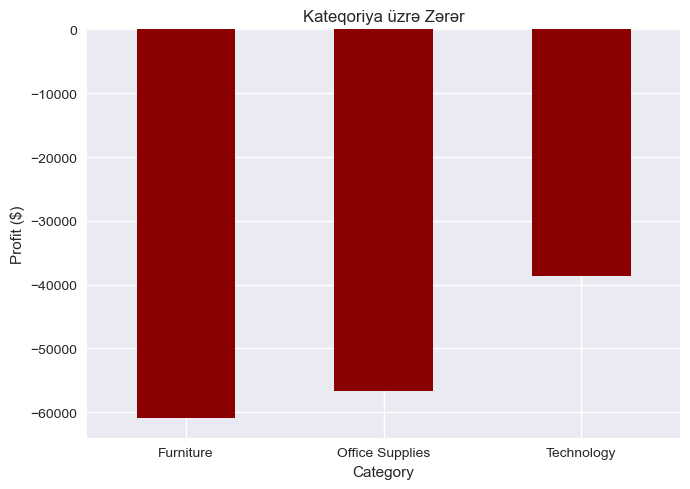

In [12]:
zererli.groupby('Category')['Profit'].sum().sort_values().plot(
    kind='bar', color='darkred', figsize=(7,5)
)
plt.title('Kateqoriya üzrə Zərər')
plt.ylabel('Profit ($)')
plt.xlabel('Category')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

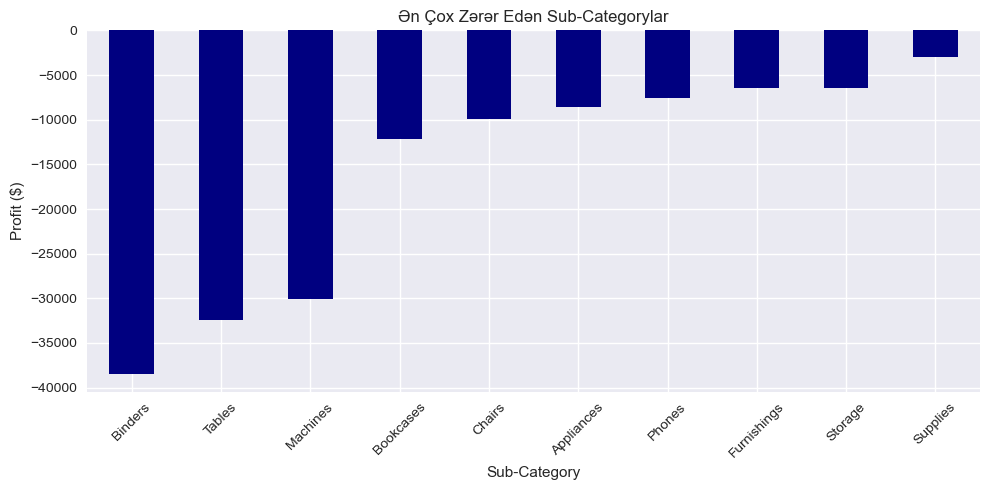

In [13]:
zererli.groupby('Sub-Category')['Profit'].sum().sort_values().head(10).plot(
    kind='bar', color='navy', figsize=(10,5)
)
plt.title('Ən Çox Zərər Edən Sub-Categorylar')
plt.ylabel('Profit ($)')
plt.xlabel('Sub-Category')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

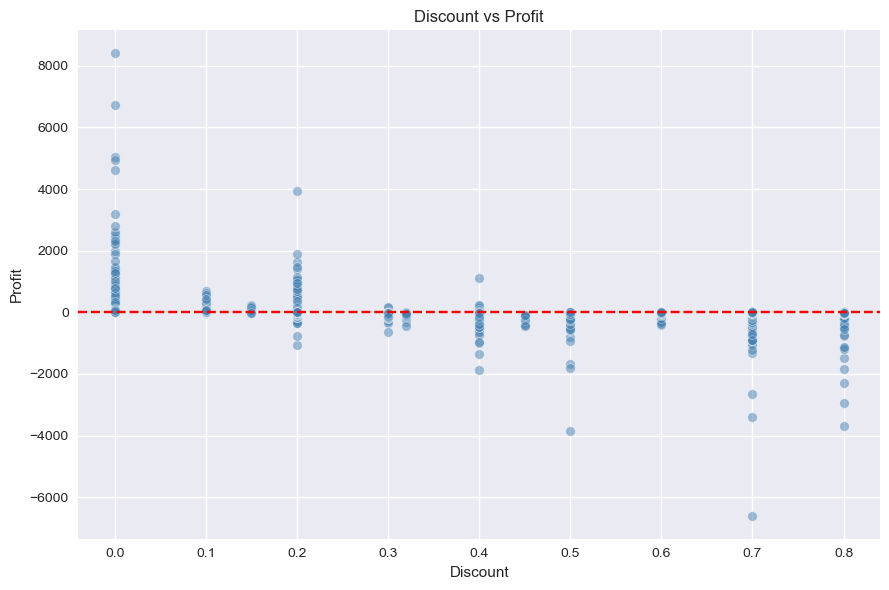

In [14]:
plt.figure(figsize=(9,6))
sns.scatterplot(data=df, x='Discount', y='Profit', alpha=0.5, color='steelblue')
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Discount vs Profit')
plt.xlabel('Discount')
plt.ylabel('Profit')
plt.tight_layout()
plt.show()

In [15]:
print(df.groupby('Discount')['Profit'].mean().round(2))

Discount
0.00     66.90
0.10     96.06
0.15     27.29
0.20     24.70
0.30    -45.68
0.32    -88.56
0.40   -111.93
0.45   -226.65
0.50   -310.70
0.60    -43.08
0.70    -95.87
0.80   -101.80
Name: Profit, dtype: float64


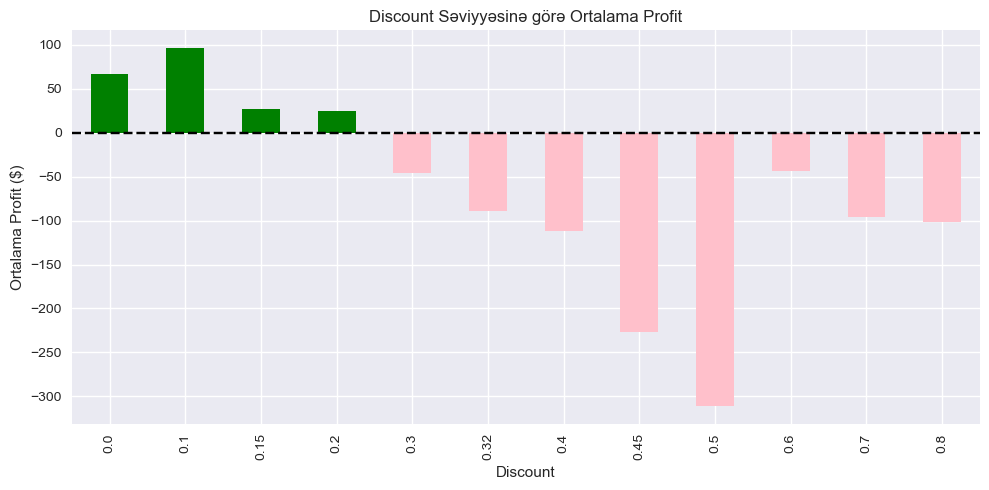

In [16]:
df.groupby('Discount')['Profit'].mean().plot(
    kind='bar', figsize=(10,5), 
    color=['green' if x > 0 else 'pink' 
           for x in df.groupby('Discount')['Profit'].mean()]
)
plt.axhline(y=0, color='black', linestyle='--')
plt.title('Discount Səviyyəsinə görə Ortalama Profit')
plt.ylabel('Ortalama Profit ($)')
plt.xlabel('Discount')
plt.tight_layout()
plt.show()

In [17]:
region_analysis = df.groupby('Region')[['Sales', 'Profit']].sum().round(2)
print(region_analysis)

             Sales     Profit
Region                       
Central  501239.89   39706.36
East     678781.24   91522.78
South    391721.90   46749.43
West     725457.82  108418.45


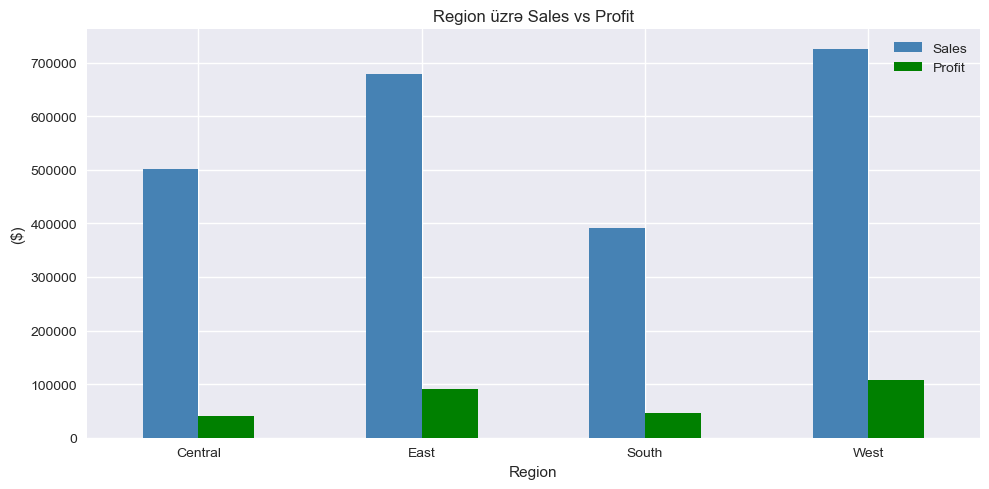

In [18]:
region_analysis.plot(kind='bar', figsize=(10,5), color=['steelblue', 'green'])
plt.title('Region üzrə Sales vs Profit')
plt.ylabel('($)')
plt.xlabel('Region')
plt.xticks(rotation=0)
plt.legend(['Sales', 'Profit'])
plt.tight_layout()
plt.show()

In [19]:
top_customers = df.groupby('Customer Name')['Sales'].sum().sort_values(ascending=False).head(10)
print(top_customers)

Customer Name
Sean Miller           25043.050
Tamara Chand          19052.218
Raymond Buch          15117.339
Tom Ashbrook          14595.620
Adrian Barton         14473.571
Ken Lonsdale          14175.229
Sanjit Chand          14142.334
Hunter Lopez          12873.298
Sanjit Engle          12209.438
Christopher Conant    12129.072
Name: Sales, dtype: float64


In [20]:
top_customers_profit = df.groupby('Customer Name')['Profit'].sum().sort_values(ascending=False).head(10)
print(top_customers_profit)

Customer Name
Tamara Chand            8981.3239
Raymond Buch            6976.0959
Sanjit Chand            5757.4119
Hunter Lopez            5622.4292
Adrian Barton           5444.8055
Tom Ashbrook            4703.7883
Christopher Martinez    3899.8904
Keith Dawkins           3038.6254
Andy Reiter             2884.6208
Daniel Raglin           2869.0760
Name: Profit, dtype: float64


In [21]:
sean = df[df['Customer Name'] == 'Sean Miller'][['Sales', 'Discount', 'Profit']]
print(sean.describe())

              Sales   Discount       Profit
count     15.000000  15.000000    15.000000
mean    1669.536667   0.246667  -132.049287
std     5807.087126   0.184649   467.115828
min        3.488000   0.000000 -1811.078400
25%       14.448000   0.200000    -8.561800
50%       30.768000   0.200000     3.802400
75%      324.401000   0.200000     7.779100
max    22638.480000   0.700000    31.587000


In [22]:
max_date = df['Order Date'].max()

rfm = df.groupby('Customer Name').agg(
    Recency=('Order Date', lambda x: (max_date - x.max()).days),
    Frequency=('Order ID', 'nunique'),
    Monetary=('Sales', 'sum')
).round(2)

print(rfm.head(10))

                    Recency  Frequency  Monetary
Customer Name                                   
Aaron Bergman           415          3    886.16
Aaron Hawkins            12          7   1744.70
Aaron Smayling           88          7   3050.69
Adam Bellavance          54          8   7755.62
Adam Hart                34         10   3250.34
Adam Shillingsburg       28          9   3255.31
Adrian Barton            41         10  14473.57
Adrian Hane              60          7   1735.51
Adrian Shami             41          2     58.82
Aimee Bixby              41          5    966.71


In [23]:
rfm['R_Score'] = pd.qcut(rfm['Recency'], q=4, labels=[4,3,2,1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=4, labels=[1,2,3,4])
rfm['M_Score'] = pd.qcut(rfm['Monetary'], q=4, labels=[1,2,3,4])

rfm['RFM_Score'] = rfm['R_Score'].astype(int) + rfm['F_Score'].astype(int) + rfm['M_Score'].astype(int)

rfm['Segment'] = pd.cut(rfm['RFM_Score'], bins=[0,5,8,12], labels=['Low Value', 'Mid Value', 'High Value'])

print(rfm['Segment'].value_counts())

Segment
High Value    315
Mid Value     281
Low Value     197
Name: count, dtype: int64


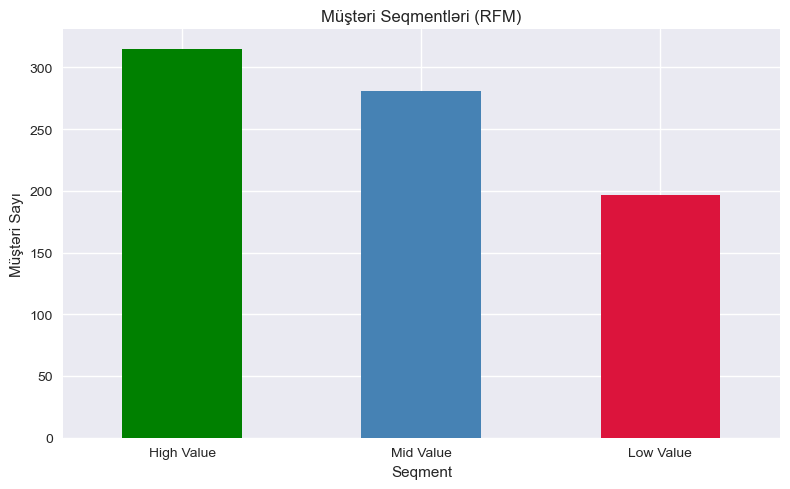

In [24]:
rfm['Segment'].value_counts().plot(
    kind='bar', 
    color=['green', 'steelblue', 'crimson'], 
    figsize=(8,5)
)
plt.title('Müştəri Seqmentləri (RFM)')
plt.ylabel('Müştəri Sayı')
plt.xlabel('Seqment')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [25]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# RFM dəyərlərini götür
X = rfm[['Recency', 'Frequency', 'Monetary']]

# Normallaşdır
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# KMeans - 4 cluster
kmeans = KMeans(n_clusters=4, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(X_scaled)

print(rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean().round(2))

         Recency  Frequency  Monetary
Cluster                              
0         549.67       3.76   1497.45
1          71.71       8.57   3361.45
2         123.86       8.22   9522.70
3          96.84       4.76   1669.50


C:\Users\l\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


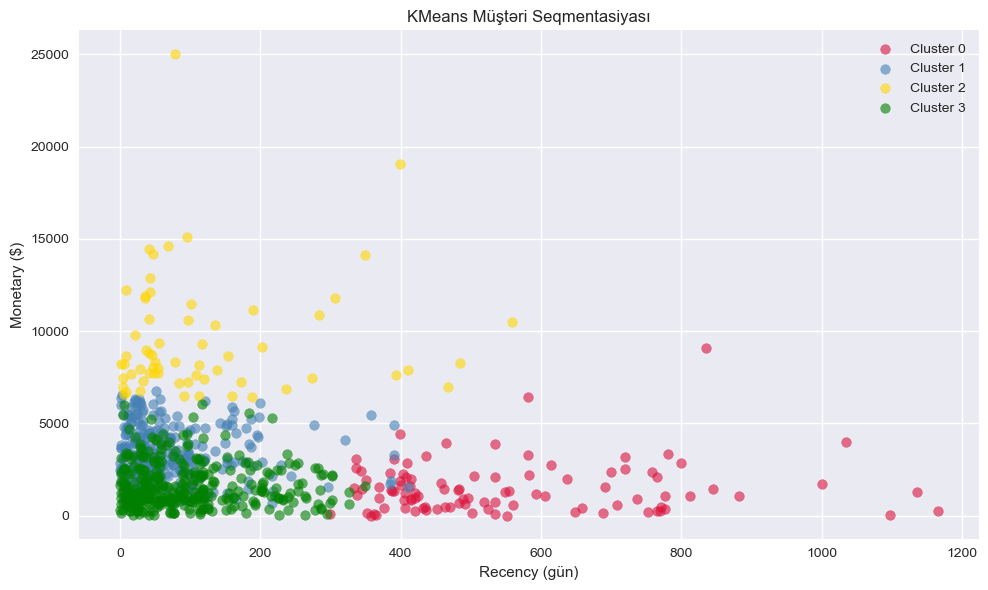

In [26]:
plt.figure(figsize=(10,6))
colors = ['crimson', 'steelblue', 'gold', 'green']
for cluster in range(4):
    data = rfm[rfm['Cluster'] == cluster]
    plt.scatter(data['Recency'], data['Monetary'], 
                c=colors[cluster], label=f'Cluster {cluster}', alpha=0.6)

plt.title('KMeans Müştəri Seqmentasiyası')
plt.xlabel('Recency (gün)')
plt.ylabel('Monetary ($)')
plt.legend()
plt.tight_layout()
plt.show()

In [27]:
df.groupby('Customer Name')['Sales'].sum().sort_values(ascending=False).head(10)

Customer Name
Sean Miller           25043.050
Tamara Chand          19052.218
Raymond Buch          15117.339
Tom Ashbrook          14595.620
Adrian Barton         14473.571
Ken Lonsdale          14175.229
Sanjit Chand          14142.334
Hunter Lopez          12873.298
Sanjit Engle          12209.438
Christopher Conant    12129.072
Name: Sales, dtype: float64

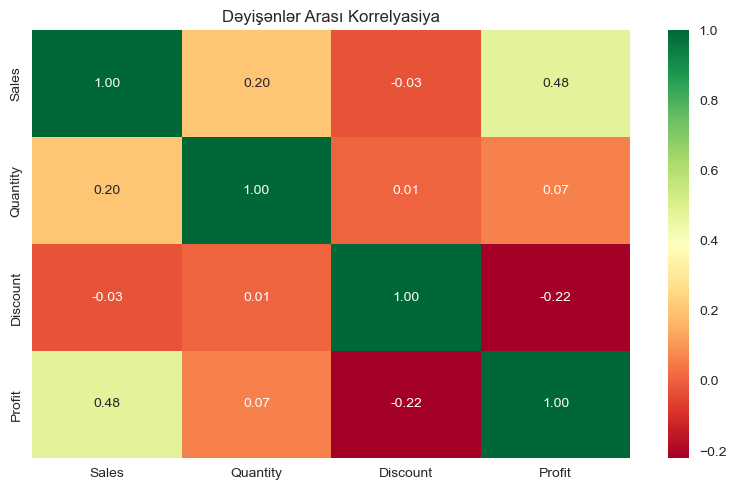

In [35]:
plt.figure(figsize=(8,5))
sns.heatmap(df[['Sales', 'Quantity', 'Discount', 'Profit']].corr(), 
            annot=True, cmap='RdYlGn', fmt='.2f')
plt.title('Dəyişənlər Arası Korrelyasiya')
plt.tight_layout()
plt.show()

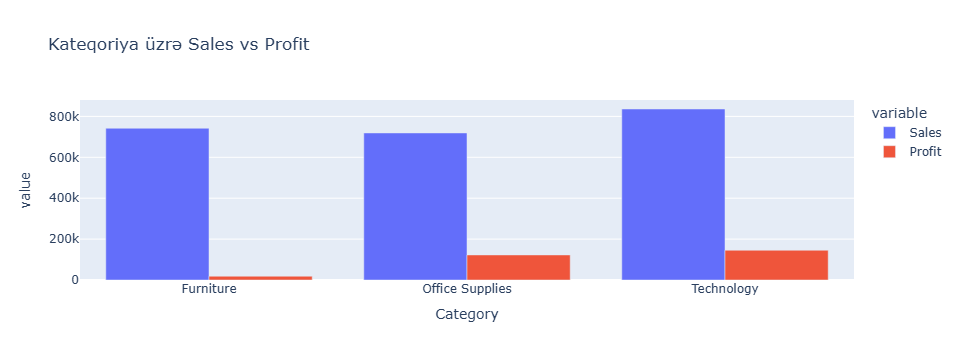

In [37]:
fig = px.bar(df.groupby('Category')[['Sales','Profit']].sum().reset_index(), 
             x='Category', y=['Sales','Profit'],
             title='Kateqoriya üzrə Sales vs Profit',
             barmode='group')
fig.show()

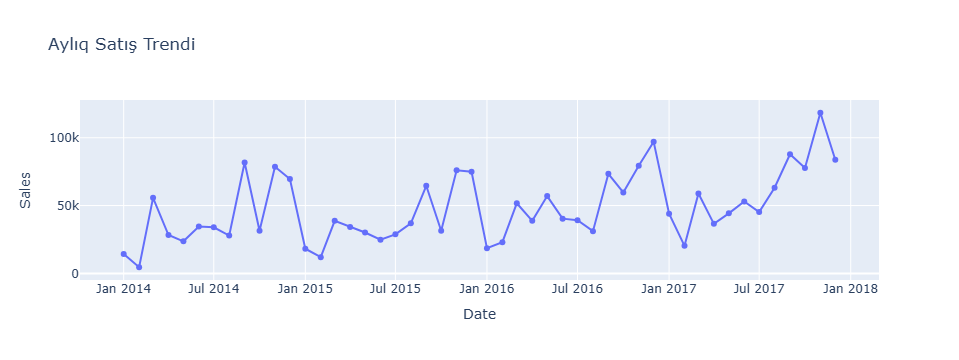

In [38]:
monthly = df.groupby(['Order Year', 'Order Month'])['Sales'].sum().reset_index()
monthly['Date'] = pd.to_datetime(monthly[['Order Year', 'Order Month']].assign(day=1).rename(columns={'Order Year':'year', 'Order Month':'month'}))

fig = px.line(monthly, x='Date', y='Sales', 
              title='Aylıq Satış Trendi',
              markers=True)
fig.show()

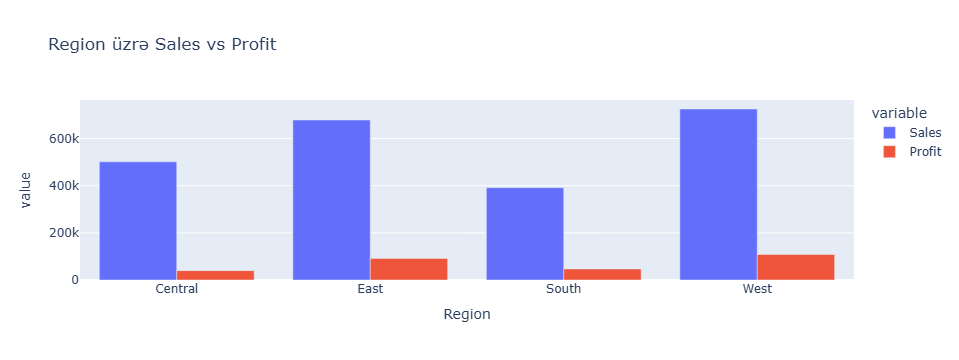

In [39]:
fig = px.bar(df.groupby('Region')[['Sales','Profit']].sum().reset_index(),
             x='Region', y=['Sales','Profit'],
             title='Region üzrə Sales vs Profit',
             barmode='group')
fig.show()

In [40]:
high_sales_low_profit = df.groupby('Product Name').agg(
    Sales=('Sales', 'sum'),
    Profit=('Profit', 'sum')
).reset_index()

high_sales_low_profit = high_sales_low_profit[
    (high_sales_low_profit['Sales'] > 5000) & 
    (high_sales_low_profit['Profit'] < 0)
].sort_values('Sales', ascending=False).head(10)

print(high_sales_low_profit)

                                           Product Name       Sales     Profit
444   Cisco TelePresence System EX90 Videoconferenci...  22638.4800 -1811.0784
683           GBC DocuBind P400 Electric Binding System  17965.0680 -1878.1662
813         High Speed Automatic Electric Letter Opener  17030.3120  -262.0048
985           Lexmark MX611dhe Monochrome Laser Printer  16829.9010 -4589.9730
1043  Martin Yale Chadless Opener Electric Letter Op...  16656.2000 -1299.1836
1351  Riverside Palais Royal Lawyers Bookcase, Royal...  15610.9656  -669.5448
368          Bretford Rectangular Conference Table Tops  12995.2915  -327.2331
475           Cubify CubeX 3D Printer Double Head Print  11099.9630 -8879.9704
425   Chromcraft Bull-Nose Wood Oval Conference Tabl...   9917.6400 -2876.1156
376   Bush Advantage Collection Racetrack Conference...   9544.7250 -1934.3976


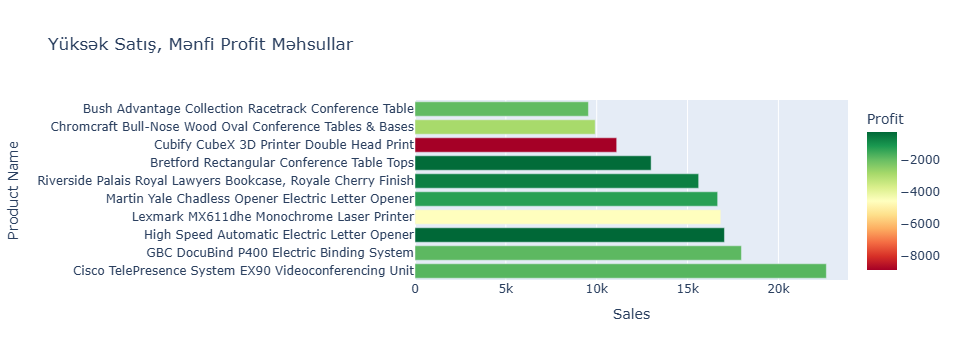

In [43]:
fig = px.bar(high_sales_low_profit, 
             x='Sales', y='Product Name',
             color='Profit',
             color_continuous_scale='RdYlGn',
             title='Yüksək Satış, Mənfi Profit Məhsullar',
             orientation='h')
fig.show()

In [44]:
customer_orders = df.groupby('Customer Name')['Order ID'].nunique()

one_time = (customer_orders == 1).sum()
repeat = (customer_orders > 1).sum()

print(f"Bir dəfə alan müştərilər: {one_time}")
print(f"Dəfələrlə alan müştərilər: {repeat}")
print(f"Loyal müştəri faizi: {round(repeat / len(customer_orders) * 100, 2)}%")

Bir dəfə alan müştərilər: 12
Dəfələrlə alan müştərilər: 781
Loyal müştəri faizi: 98.49%


In [47]:
aov = df.groupby('Order ID')['Sales'].sum()
print(f"Ortalama Sifariş Dəyəri: ${round(aov.mean(), 2)}")
print(f"Ən böyük sifariş: ${round(aov.max(), 2)}")
print(f"Ən kiçik sifariş: ${round(aov.min(), 2)}")

Ortalama Sifariş Dəyəri: $458.61
Ən böyük sifariş: $23661.23
Ən kiçik sifariş: $0.56
